# RL coursework, part II (25 pts total)
---

**Name:** 

**SN:** 

---

**Due date:** *April 10th, 2025*

---

Standard UCL policy (including grade deductions) automatically applies for any late submissions.

## How to submit

When you have completed the exercises and everything has finished running, click on 'File' in the menu-bar and then 'Download .ipynb'. This file must be submitted to Moodle named as **`<studentnumber>_RL_part2.ipynb`** before the deadline above, where `<studentnumber>` is your student number.

----
**Reminder of copyrights**

Copyrights protect this code/content and distribution or usages of it (or parts of it) without permission is prohibited. This includes uploading it and usage of it in training in any LLMs systems.

## Context

In this part, we will take a first look at learning algorithms for sequential decision problems.

## Background reading

* Sutton and Barto (2018), Chapters 3 - 6

# The Assignment

### Objectives

You will use Python to implement several reinforcement learning algorithms.

You will then run these algorithms on a few problems, to understand their properties.

## Setup

### Import Useful Libraries

In [ ]:
import matplotlib.collections as mcoll
import matplotlib.pyplot as plt
import numpy as np

### Set options

In [ ]:
np.set_printoptions(precision=3, suppress=1)

### Some grid world

In [ ]:
W = -100  # wall
G = 100  # goal

GRID_LAYOUT = np.array([
  [W, W, W, W, W, W, W, W, W, W, W, W],
  [W, W, 0, W, W, W, W, W, W, 0, W, W],
  [W, 0, 0, 0, 0, 0, 0, 0, 0, G, 0, W],
  [W, 0, 0, 0, W, W, W, W, 0, 0, 0, W],
  [W, 0, 0, 0, W, W, W, W, 0, 0, 0, W],
  [W, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, W],
  [W, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, W],
  [W, W, 0, 0, 0, 0, 0, 0, 0, 0, W, W],
  [W, W, W, W, W, W, W, W, W, W, W, W]
])

class Grid(object):

  def __init__(self, noisy=False):
    # -1: wall
    # 0: empty, episode continues
    # other: number indicates reward, episode will terminate
    self._layout = GRID_LAYOUT
    self._start_state = (2, 2)
    self._state = self._start_state
    self._number_of_states = np.prod(np.shape(self._layout))
    self._noisy = noisy

  @property
  def number_of_states(self):
    return self._number_of_states

  def get_obs(self):
    y, x = self._state
    return y*self._layout.shape[1] + x

  def obs_to_state(self, obs):
    x = obs % self._layout.shape[1]
    y = obs // self._layout.shape[1]
    s = np.copy(grid._layout)
    s[y, x] = 4
    return s

  def step(self, action):
    y, x = self._state

    if action == 0:  # up
      new_state = (y - 1, x)
    elif action == 1:  # right
      new_state = (y, x + 1)
    elif action == 2:  # down
      new_state = (y + 1, x)
    elif action == 3:  # left
      new_state = (y, x - 1)
    else:
      raise ValueError("Invalid action: {} is not 0, 1, 2, or 3.".format(action))

    new_y, new_x = new_state
    reward = self._layout[new_y, new_x]
    if self._layout[new_y, new_x] == W:  # wall
      discount = 0.9
      new_state = (y, x)
    elif self._layout[new_y, new_x] == 0:  # empty cell
      reward = -1.
      discount = 0.9
    else:  # a goal
      discount = 0.
      new_state = self._start_state

    if self._noisy:
      width = self._layout.shape[1]
      reward += 10*np.random.normal(0, width - new_x + new_y)

    self._state = new_state
    return reward, discount, self.get_obs()

  def plot_grid(self):
    plt.figure(figsize=(4, 4))
    plt.imshow(self._layout != W, interpolation="nearest", cmap='pink')
    plt.gca().grid(0)
    plt.xticks([])
    plt.yticks([])
    plt.title("The grid")
    plt.text(2, 2, r"$\mathbf{S}$", ha='center', va='center')
    plt.text(9, 2, r"$\mathbf{G}$", ha='center', va='center')
    h, w = self._layout.shape
    for y in range(h-1):
      plt.plot([-0.5, w-0.5], [y+0.5, y+0.5], '-k', lw=2)
    for x in range(w-1):
      plt.plot([x+0.5, x+0.5], [-0.5, h-0.5], '-k', lw=2)


### Helper functions
(You should not have to change, or even look at, these.  Do run the cell to make sure the functions are loaded though.)

In [ ]:
def run_experiment(env, agent, number_of_steps):
  mean_reward = 0.
  try:
    action = agent.initial_action()
  except AttributeError:
    action = 0
  for _ in range(number_of_steps):
    reward, discount, next_state = env.step(action)
    action = agent.step(reward, discount, next_state)
    mean_reward += reward
  return mean_reward/float(number_of_steps)

map_from_action_to_subplot = lambda a: (2, 6, 8, 4)[a]
map_from_action_to_name = lambda a: ("up", "right", "down", "left")[a]

def plot_values(grid, values, colormap='pink', vmin=0, vmax=10):
  plt.imshow(values - 1000*(grid<0), interpolation="nearest", cmap=colormap, vmin=vmin, vmax=vmax)
  plt.yticks([])
  plt.xticks([])
  plt.colorbar(ticks=[vmin, vmax])

def plot_action_values(grid, action_values, vmin=-5, vmax=5):
  q = action_values
  fig = plt.figure(figsize=(10, 10))
  fig.subplots_adjust(wspace=0.3, hspace=0.3)
  for a in [0, 1, 2, 3]:
    plt.subplot(4, 3, map_from_action_to_subplot(a))
    plot_values(grid, q[..., a], vmin=vmin, vmax=vmax)
    action_name = map_from_action_to_name(a)
    plt.title(r"$q(s, \mathrm{" + action_name + r"})$")

  plt.subplot(4, 3, 5)
  v = np.max(q, axis=-1)
  plot_values(grid, v, colormap='summer', vmin=vmin, vmax=vmax)
  plt.title("$v(s)$")

  # Plot arrows:
  plt.subplot(4, 3, 11)
  plot_values(grid, grid==0, vmax=1)
  for row in range(len(grid)):
    for col in range(len(grid[0])):
      if grid[row][col] == 0:
        argmax_a = np.argmax(q[row, col])
        if argmax_a == 0:
          x = col
          y = row + 0.5
          dx = 0
          dy = -0.8
        if argmax_a == 1:
          x = col - 0.5
          y = row
          dx = 0.8
          dy = 0
        if argmax_a == 2:
          x = col
          y = row - 0.5
          dx = 0
          dy = 0.8
        if argmax_a == 3:
          x = col + 0.5
          y = row
          dx = -0.8
          dy = 0
        plt.arrow(x, y, dx, dy, width=0.02, head_width=0.4, head_length=0.4, length_includes_head=True, fc='k', ec='k')

def plot_rewards(xs, rewards, color):
  mean = np.mean(rewards, axis=0)
  p90 = np.percentile(rewards, 90, axis=0)
  p10 = np.percentile(rewards, 10, axis=0)
  plt.plot(xs, mean, color=color, alpha=0.6)
  plt.fill_between(xs, p90, p10, color=color, alpha=0.3)

def parameter_study(parameter_values, parameter_name, agent_constructor,
                    env_constructor, color,
                    repetitions=10, number_of_steps=int(1e4)):
  mean_rewards = np.zeros((repetitions, len(parameter_values)))
  greedy_rewards = np.zeros((repetitions, len(parameter_values)))
  for rep in range(repetitions):
    for i, p in enumerate(parameter_values):
      env = env_constructor()
      agent = agent_constructor()
      if 'eps' in parameter_name:
        agent.set_epsilon(p)
      elif 'alpha' in parameter_name:
        agent._step_size = p
      else:
        raise NameError("Unknown parameter_name: {}".format(parameter_name))
      mean_rewards[rep, i] = run_experiment(env, agent, number_of_steps)
      agent.set_epsilon(0.)
      agent._step_size = 0.
      greedy_rewards[rep, i] = run_experiment(env, agent, number_of_steps//10)
      del env
      del agent

  plt.subplot(1, 2, 1)
  plot_rewards(parameter_values, mean_rewards, color)
  plt.yticks=([0, 1], [0, 1])
  plt.ylabel("Average reward over first {} steps".format(number_of_steps), size=12)
  plt.xlabel(parameter_name, size=12)

  plt.subplot(1, 2, 2)
  plot_rewards(parameter_values, greedy_rewards, color)
  plt.yticks=([0, 1], [0, 1])
  plt.ylabel("Final rewards, with greedy policy".format(number_of_steps), size=12)
  plt.xlabel(parameter_name, size=12)

def epsilon_greedy(q_values, epsilon):
  if epsilon < np.random.random():
    return np.argmax(q_values)
  else:
    return np.random.randint(np.array(q_values).shape[-1])


def colorline(x, y, z):
  """
  Based on:
  http://nbviewer.ipython.org/github/dpsanders/matplotlib-examples/blob/master/colorline.ipynb
  http://matplotlib.org/examples/pylab_examples/multicolored_line.html
  Plot a colored line with coordinates x and y
  Optionally specify colors in the array z
  Optionally specify a colormap, a norm function and a line width
  """
  segments = make_segments(x, y)
  lc = mcoll.LineCollection(segments, array=z, cmap=plt.get_cmap('copper_r'),
                            norm=plt.Normalize(0.0, 1.0), linewidth=3)

  ax = plt.gca()
  ax.add_collection(lc)
  return lc


def make_segments(x, y):
  """
  Create list of line segments from x and y coordinates, in the correct format
  for LineCollection: an array of the form numlines x (points per line) x 2 (x
  and y) array
  """
  points = np.array([x, y]).T.reshape(-1, 1, 2)
  segments = np.concatenate([points[:-1], points[1:]], axis=1)
  return segments


def plotting_helper_function(_x, _y, title=None, ylabel=None):
  z = np.linspace(0, 0.9, len(_x))**0.7
  colorline(_x, _y, z)
  plt.plot(0, 0, '*', color='#000000', ms=20, alpha=0.7, label='$w^*$')
  plt.plot(1, 1, '.', color='#ee0000', alpha=0.7, ms=20, label='$w_0$')
  min_y, max_y = np.min(_y), np.max(_y)
  min_x, max_x = np.min(_x), np.max(_x)
  min_y, max_y = np.min([0, min_y]), np.max([0, max_y])
  min_x, max_x = np.min([0, min_x]), np.max([0, max_x])
  range_y = max_y - min_y
  range_x = max_x - min_x
  max_range = np.max([range_y, range_x])
  plt.arrow(_x[-3], _y[-3], _x[-1] - _x[-3], _y[-1] - _y[-3], color='k',
            head_width=0.04*max_range, head_length=0.04*max_range,
            head_starts_at_zero=False)
  plt.ylim(min_y - 0.2*range_y, max_y + 0.2*range_y)
  plt.xlim(min_x - 0.2*range_x, max_x + 0.2*range_x)
  ax = plt.gca()
  ax.ticklabel_format(style='plain', useMathText=True)
  plt.legend(loc=2)
  plt.xticks(rotation=12, fontsize=10)
  plt.yticks(rotation=12, fontsize=10)
  plt.locator_params(nbins=3)
  if title is not None:
    plt.title(title, fontsize=20)
  if ylabel is not None:
    plt.ylabel(ylabel, fontsize=20)


# Section A: Tabular RL

In this section, observations will be states in the environment, so the agent state, environment state, and observation will all be the same, and we will use the word `state` interchangably with `observation`.  You will implement agents, which should be in pure Python - so you cannot use JAX/TensorFlow/PyTorch to compute gradients. Using `numpy` is fine.

### A random agent

Below we show a reference implementation of a simple random agent, implemented according to the interface above.

In [ ]:
class Random(object):

  def __init__(self, number_of_actions, number_of_states, initial_state):
    self._number_of_actions = number_of_actions

  def step(self, reward, discount, next_state):
    next_action = np.random.randint(self._number_of_actions)
    return next_action

### The grid

The cell below shows the `Grid` environment that we will use in this section. Here `S` indicates the start state and `G` indicates the goal.  The agent has four possible actions: up, right, down, and left.  Rewards are: `-100` for bumping into a wall, `+100` for reaching the goal, and `-1` otherwise.  The episode ends when the agent reaches the goal, and otherwise continues.  The discount, on continuing steps, is $\gamma = 0.9$.  Feel free to reference the implemetation of the `Grid` above, under the header "a grid world".

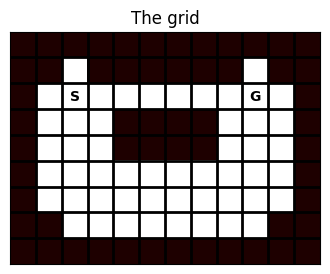

In [ ]:
GRID = Grid()
GRID.plot_grid()


## Q1: Implement TD learning **[4 pts]**
Implement an agent that acts randomly, and _on-policy_ estimates state values $v(s)$, using one-step TD learning with step size $\alpha=0.1$.

Use the `__init__` as provided below.  You should implement the `step` function.  We store the initial state in the constructor because you need its value on the first `step` in order to compute the TD error when the first transition has occurred.

Also implement a property `state_values(self)` returning the vector of all state values (one value per state). (A method with the `@property` decorator can be called without the parentheses as if it's a variable, e.g., `agent.state_values` instead of `agent.state_values()`.)

In [ ]:
class RandomTD(object):

  def __init__(self, number_of_states, number_of_actions, initial_state, step_size=0.1):
    self._number_of_states = number_of_states
    self._number_of_actions = number_of_actions
    self._state = initial_state
    self._step_size = step_size
    self._state_values = np.zeros(number_of_states)

  @property
  def state_values(self):
    return self._state_values

  def step(self, reward, discount, next_state):
    self._state_values[self._state] += self._step_size * (reward + discount * self._state_values[next_state] - self._state_values[self._state])
    self._state = next_state
    action = np.random.randint(self._number_of_actions)
    return action

### Run the next cell to run the `RandomTD` agent on a grid world.

If everything worked as expected, the plot below will show the estimates state values under the random policy. This includes values for unreachable states --- on the walls and on the goal (we never actually reach the goal --- rather, the episode terminates on the transition to the goal.  The values on the walls and goal are, and will always remain, zero. The plotting code knows about the walls, so they appear black below.

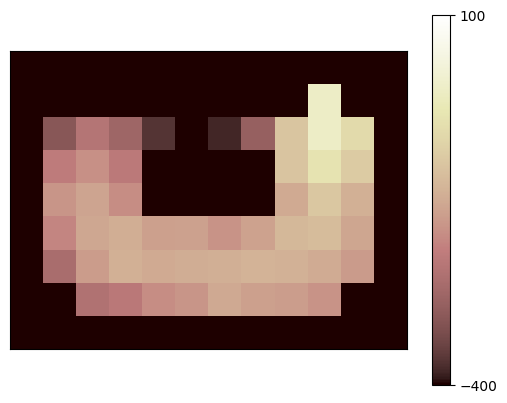

In [ ]:
# Do not modify this cell.
AGENT = RandomTD(GRID._layout.size, 4, GRID.get_obs())
run_experiment(GRID, AGENT, int(1e5))
v = AGENT.state_values
plot_values(GRID_LAYOUT,
            v.reshape(GRID._layout.shape),
            colormap="pink", vmin=-400, vmax=100)

## Q2: Policy iteration **[5 pts]**
We used TD to do policy evaluation for the random policy on this problem.  Consider doing policy improvement, by taking the greedy policy with respect to a one-step look-ahead.  For this, you may assume we have a true model, so for each state and for each action we can look at the value of the resulting state, and would then pick the action with the highest reward plus subsequent state value. In other words, you can assume we can use $q(s, a) = \mathbb{E}[ R_{t+1} + \gamma v(S_{t+1}) \mid S_t = s, A_t = a]$, where $v$ is the value function learned by TD as implemented. Then we consider the policy that picks the action with the highest action value $q(s, a)$. You do **not** have to implement this, just answer the following question.

2.1 **[3pts]** The above amounts to performing an iteration of policy evaluation and policy improvement.  If we repeat this process over and over again, and repeatedly evaluate the greedy policy and then perform an improvement step by picking the greedy policy, would the policy eventually become optimal?  Explain why or why not in at most three sentences.

> Yes, the iterative process of TD-based policy evaluation and greedy policy improvement with true model converges to the optimal policy.

1. the greedy step never lowers performance
2. only finitely many policies exist and we run evaluation long enough for TD to converge
3. $v(s)$ can be calculated accurately on all states since we have true model

2.2. **[2pts]** What if you were to run a Q-learning agent on this enveromenint, and consider running to converegence, how would the value function for Q_learning compare to the one learnt by the TD agent?

> Q-learning agent learn optimal value function which is best attainable in MDP.
$$v^*(s) = \max_a q^*(s, a)$$
through an exploration policy (e.g. $\varepsilon$-greedy behaviour policy).

Because TD + greedy policy-improvement is (in effect) exact policy-iteration, it converges to the optimal state-value function  

$$v^{*}(s)=\max_{a}q^{*}(s,a).$$

Hence after both methods have converged,
* Q-learning stores a separate optimal value for every $(s,a)$ pair;  
* the TD agent stores only $v^{*}(s)$, which is exactly $\max_{a}q^{*}(s,a)$ from Q-learning.

So they will agree with same value function in every state, but Q-learning contains the extra per-action detail.

# Section B: Off-policy Bellman operators with function approximation

## Q1: Bellman operator for prediction **[5 pts]**

We are going to implement the _expected_ update to the weight for a simple MDP.
In order to be able to implement this update, we need to know the MDP, as well as the way the agent's value depend on the weights and states.  This is defined as follows:

There are two states, $s_1$ and $s_2$.  All rewards are zero, and therefore can be ignored.  Instead of the underlying state, the agent observes state features $\mathbf{x}_1 = \mathbf{x}(s_1)$ and $\mathbf{x}_2 = \mathbf{x}(s_2)$.  These are defined for the two states are $\mathbf{x}_1 = [1, 1]^{\top}$ and $\mathbf{x}_2 = [2, 1]^{\top}$.  In each state, there are two actions, $a$ and $b$.  Action $a$ always transitions to state $s_1$, action $b$ always transitions to state $s_2$.

![MDP](https://hadovanhasselt.files.wordpress.com/2020/02/mdp.png)

---

The agent will make *linear* predicions, such that $v(s) = \mathbf{w}^\top \mathbf{x}(s)$. In the code cell below, you should implement an update that computes the **expected** weight update, given:
* The current weights `w`.
* A target policy $\pi$ that we want to learn about; the actual input, denoted `pi` in the code below, will be a scalar indicating the probability of selecting action `a` in both states: `pi` $= \pi(a|s), \forall s$.
* A behaviour policy $\mu$ that would be used to generate the transitions; the actual input, denoted `mu` in the code below, will be a scalar indicating the probability of selecting action `a` in both states: `mu` $= \mu(a|s), \forall s$.
* A scalar trace parameter $\lambda$ (=`trace_parameter`),
* A scalar discount parameter $\gamma$ (=`discount`).

The expectation should take into account the probabilities of actions in the future, as well as the steady-state (=long-term) probability of being in a state.  The step size of the update should be $\alpha=0.1$.

The expected update should be for a multi-step $\lambda$-return and should be correct for any pair of target and any behaviour policy.  It should be the expectation of performing a (forward view) TD($\lambda$) update in the MDP described above when the _state distribution_ is generated by the behaviour policy and the _returns_ from each state are generated by the target policy. We will use the update you implement to generate plots below.


In [ ]:
# state features (do not change)
x1 = np.array([1., 1.])
x2 = np.array([2., 1.])

def expected_update(w, pi, mu, trace_parameter, discount, lr):
  v_target = np.dot(w, pi * x1 + (1 - pi) * x2)
  G_rho_lambda = (1 - trace_parameter) * discount / (1 - trace_parameter * discount) * v_target
  TD_1 = G_rho_lambda - np.dot(w, x1)
  TD_2 = G_rho_lambda - np.dot(w, x2)
  expected_weight_update = lr * (TD_1 * mu * x1 + TD_2 * (1 - mu) * x2)
  return expected_weight_update

##Experiment: run the cell below
The cell below runs an experiment, across different target policies and trace parameters $\lambda$.

The plots below the cell will show how the weights move within the 2-dimensional weight space, starting from $w_0 = [1, 1]^{\top}$ (shown as red dot).  The optimal solution $w_* = [0, 0]^{\top}$ is also shown (as black star).

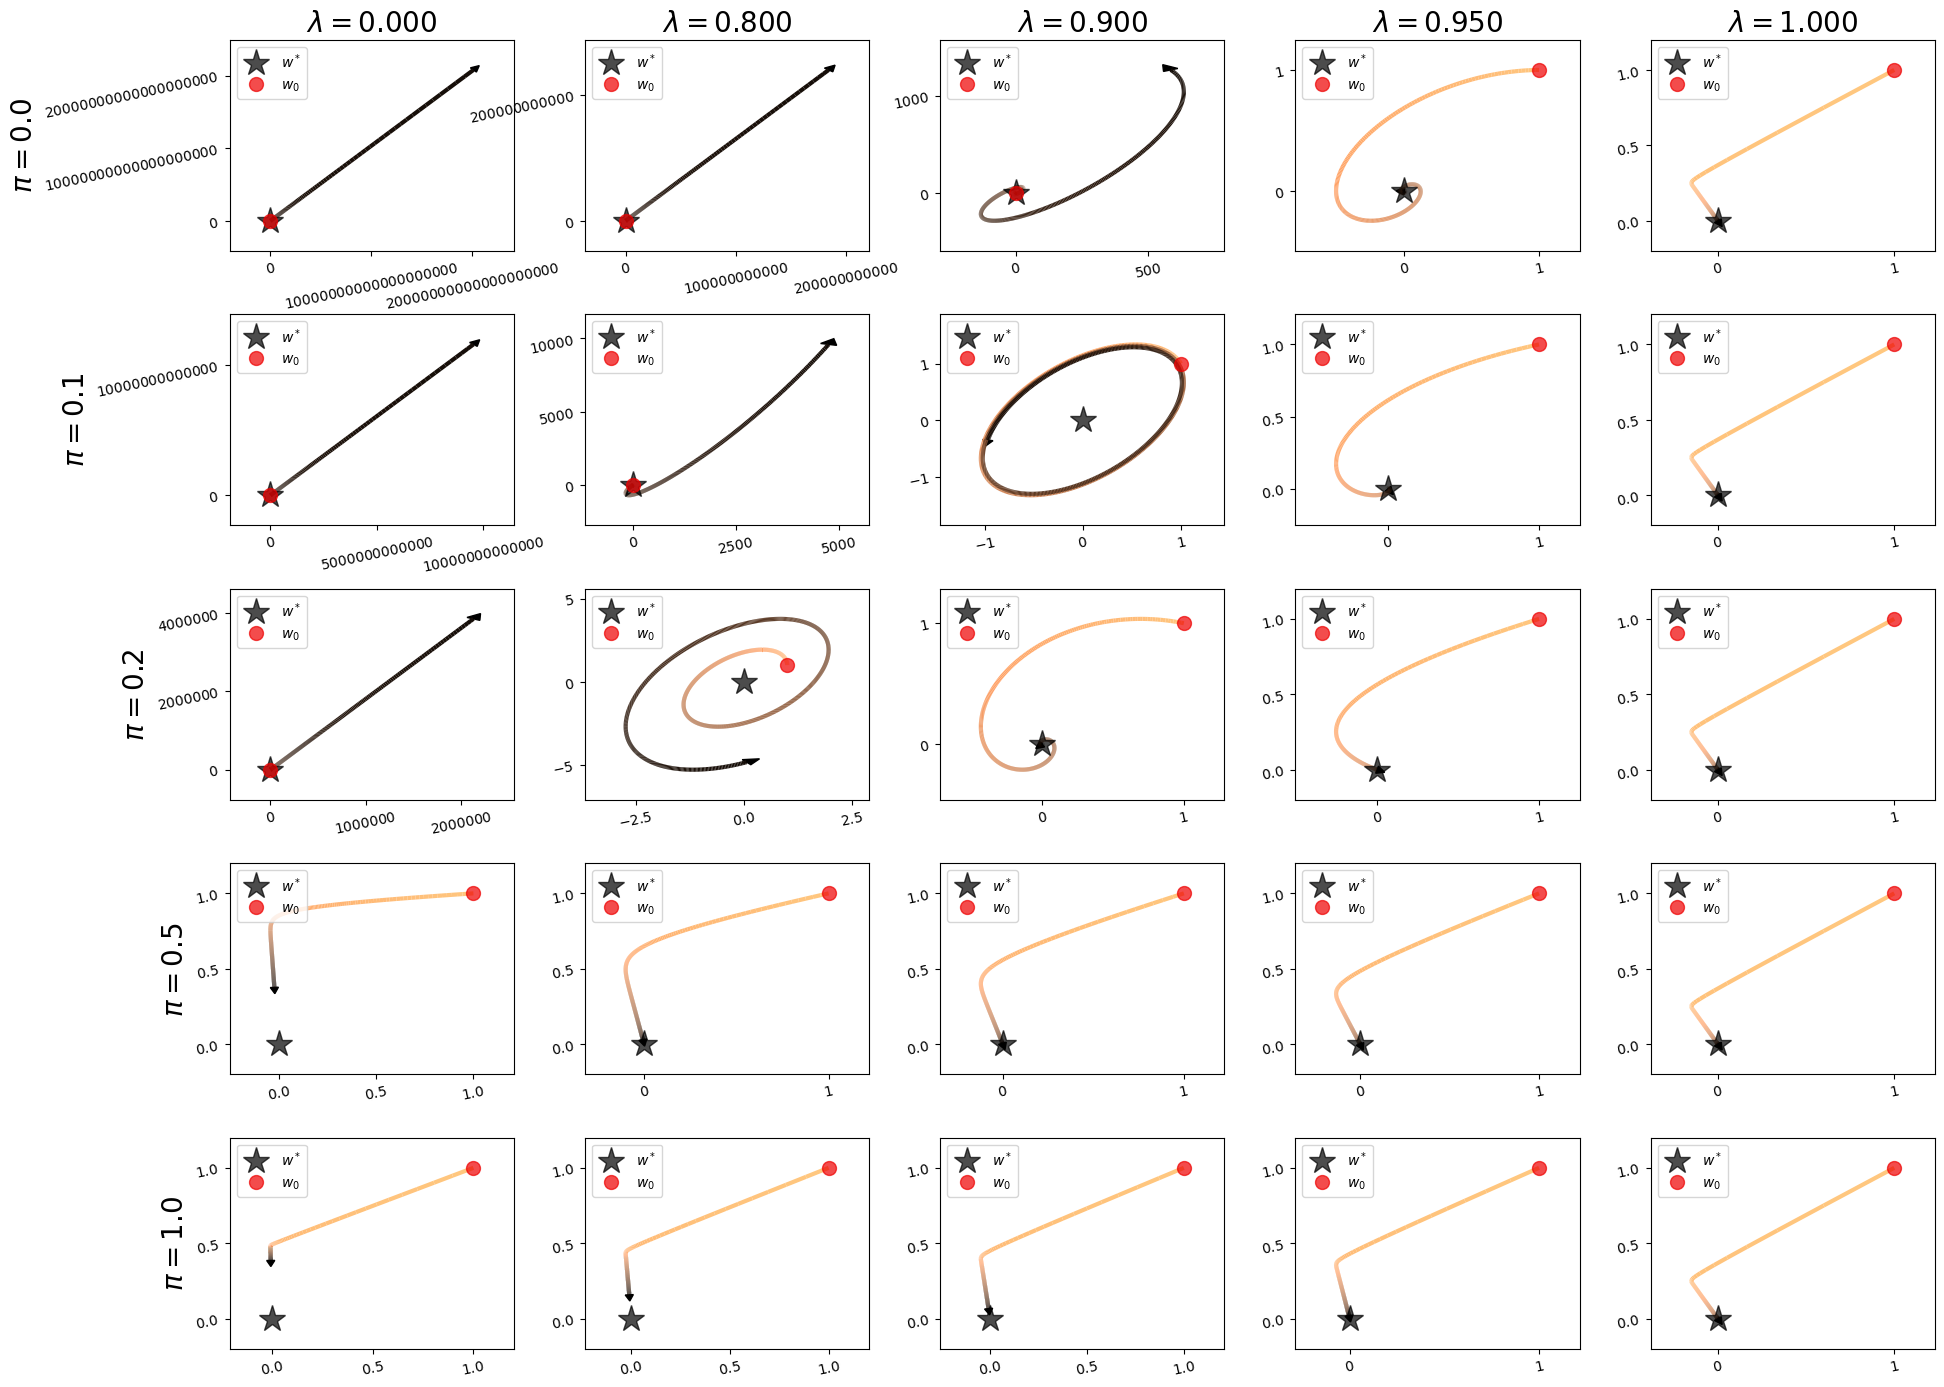

In [ ]:
def generate_ws(w, pi, mu, l, g):
  """Apply the expected update 1000 times"""
  ws = [w]
  for _ in range(1000):
    w = w + expected_update(w, pi, mu, l, g, lr=0.1)
    ws.append(w)
  return np.array(ws)

mu = 0.5  # behaviour
g = 0.99  # discount

lambdas = np.array([0, 0.8, 0.9, 0.95, 1.])
pis = np.array([0., 0.1, 0.2, 0.5, 1.])

fig = plt.figure(figsize=(22, 17))
fig.subplots_adjust(wspace=0.25, hspace=0.3)

for r, pi in enumerate(pis):
  for c, l in enumerate(lambdas):
    plt.subplot(len(pis), len(lambdas), r*len(lambdas) + c + 1)
    w = np.ones_like(x1)
    ws = generate_ws(w, pi, mu, l, g)
    title = '$\\lambda={:1.3f}$'.format(l) if r == 0 else None
    ylabel = '$\\pi={:1.1f}$'.format(pi) if c == 0 else None
    plotting_helper_function(ws[:, 0], ws[:, 1], title, ylabel)

## Q2: Analyse results (11 pts total)
1. **[1 pts]** How many of the above 25 experiments diverge?
1. **[1 pts]** For which policies $\pi$, is the true value function $v_{\pi}$ representable in the above feature space (spanned by $x_1, x_2$).
1. **[2 pts]** Why are the results asymmetric across different $\pi$?  In particular, explain why the results look different when comparing $\pi = \pi(a | \cdot) = 0$ to $\pi(a | \cdot) = 1$.
1. **[2 pts]** For which combination of $\pi(a)$ and $\lambda$ does the expected update (with uniform random behaviour) converge? Do not limit the answer to the subset of values in the plots above, but to all possible choices of $\lambda \in [0, 1]$ and $\pi(a|s) \in [0, 1]$, but do restrict yourself to state-less policies, as above, for which the action probabilities are equal in the two states: $\pi(a|s_1) = \pi(a|s_2)$.
1. **[1 pts]** Why do all the plots corresponding to full Monte Carlo update look the same (right column)?
1. **[2 pts]** Why do the plots corresponding to full Monte Carlo have the shape they do?
1. **[2 pts]** The plots above are for uniform behavoiur: $\mu(a|s) = \mu(b|s) = 0.5$.  How would the results change (high level, not in terms of precise plots) if the behaviour policy $\mu$ would select action $a$ more often (e.g., $\mu = 0.8$)?  How would the results change if the behaviour would select $a$ less often (e.g., $\mu = 0.2$)?


## Put answers to Q8 in this cell:
1. 7 out of 25 experiments diverge. They are (order in $\pi, \lambda$): [0, 0],
[0, 0.8], [0, 0.9], [0.1, 0], [0.1, 0.8], [0.2, 0] and [0.2, 0.8].
Additionally, experiements [0.5, 0], [0.1, 0.9], [1.0, 0] and [1.0, 0.8] show slow convergence.
----
2. Given there is no rewards at all and there is no termination state, we can calculate the true values for both states are 0. Since $w^* = [0, 0]^\top$, no matter what $\pi$ we choose, the true value function can be representable by $x_1$ and $x_2$. So the answer is all policies $\pi \in [0, 1]$.
----
3. Given the expected update for the weights in the MDP, we compute $\Delta \mathbf{w}$ as a matrix operation and evaluate it for specific values of $\mu$ and $\pi$.

$$ v_\pi = \mathbf{w}^\top (\pi \mathbf{x}_1 + (1 - \pi) \mathbf{x}_2) = \mathbf{w}^\top \begin{bmatrix} 2 - \pi \\ 1 \end{bmatrix} = (2 - \pi) w_1 + w_2 $$
$$G^\lambda = \frac{(1 - \lambda) \gamma}{1 - \lambda \gamma} v_\pi = \frac{(1 - \lambda) \gamma}{1 - \lambda \gamma} \left[ (2 - \pi) w_1 + w_2 \right]$$
Let $D = \frac{(1 - \lambda) \gamma}{1 - \lambda \gamma}$, we have TD errors:
  $$\text{TD}_1 = G^\lambda - \mathbf{w}^\top \mathbf{x}_1 = D \left[ (2 - \pi) w_1 + w_2 \right] - (w_1 + w_2) = \left[ (2 - \pi) D - 1 \right] w_1 + (D - 1) w_2$$
  $$ \text{TD}_2 = G^\lambda - \mathbf{w}^\top \mathbf{x}_2 = D \left[ (2 - \pi) w_1 + w_2 \right] - (2 w_1 + w_2) = \left[ (2 - \pi) D - 2 \right] w_1 + (D - 1) w_2 $$

$$
\Delta \mathbf{w} = \alpha \left[ \mu \text{TD}_1 \mathbf{x}_1 + (1 - \mu) \text{TD}_2 \mathbf{x}_2 \right]
$$

Substitute the TD errors:

$$
\Delta \mathbf{w} = \alpha \begin{bmatrix} \mu \left[ \left[ (2 - \pi) D - 1 \right] w_1 + (D - 1) w_2 \right] + (1 - \mu) \left[ 2 \left[ (2 - \pi) D - 2 \right] w_1 + 2 (D - 1) w_2 \right] \\ \mu \left[ \left[ (2 - \pi) D - 1 \right] w_1 + (D - 1) w_2 \right] + (1 - \mu) \left[ \left[ (2 - \pi) D - 2 \right] w_1 + (D - 1) w_2 \right] \end{bmatrix}
$$

Group terms:

$$
\Delta \mathbf{w} = \alpha \begin{bmatrix} (2 - \pi) (2 - \mu) D + 3 \mu - 4 & (D - 1) (2 - \mu) \\ (2 - \pi) D + \mu - 2 & (D - 1) \end{bmatrix} \begin{bmatrix} w_1 \\ w_2 \end{bmatrix}
$$

In our case $\mu = 0.5$

$$
\Delta \mathbf{w}
= \frac{\alpha}{2} \begin{bmatrix} 3 (2 - \pi) D - 5 & 3 (D - 1) \\ 2 (2 - \pi) D - 3 & 2 (D - 1) \end{bmatrix} \begin{bmatrix} w_1 \\ w_2 \end{bmatrix}
$$

When $\pi = 0$

$$
\Delta \mathbf{w} = \frac{\alpha}{2} \begin{bmatrix} 6 D - 5 & 3 D - 3 \\ 4 D - 3 & 2 D - 2 \end{bmatrix} \begin{bmatrix} w_1 \\ w_2 \end{bmatrix}
$$

When $\pi = 1$

$$
\Delta \mathbf{w} = \frac{\alpha}{2} \begin{bmatrix} 3 D - 5 & 3 D - 3 \\ 2 D - 3 & 2 D - 2 \end{bmatrix} \begin{bmatrix} w_1 \\ w_2 \end{bmatrix}
$$

We can see the update matrix is asymmetric for $\pi$. For smaller $\pi$, current value of $w_1$ will contribute more than the case of larger $\pi$.

----
4. Since we have:
$$
\Delta \mathbf{w}
= \frac{\alpha}{2} \begin{bmatrix} 3 (2 - \pi) D - 5 & 3 (D - 1) \\ 2 (2 - \pi) D - 3 & 2 (D - 1) \end{bmatrix} \begin{bmatrix} w_1 \\ w_2 \end{bmatrix}.
$$
Denote $$A = \begin{bmatrix} 3 (2 - \pi) D - 5 & 3 (D - 1) \\ 2 (2 - \pi) D - 3 & 2 (D - 1) \end{bmatrix} \begin{bmatrix} w_1 \\ w_2 \end{bmatrix},$$
we have
$$\mathbf{w}^{k+1} = \mathbf{w}^k + \Delta \mathbf{w} = \mathbf{w}^k + \frac{\alpha}{2}A\mathbf{w}^k = \left(I + \frac{\alpha}{2}A\right)\mathbf{w}^k.$$
So we have iteration matrix
$$M = I + \frac{\alpha}{2}A.$$
To make the sequence converges for every starting vector, we need to have spectual radius of $M$ smaller than 1, i.e.
$$\rho(M) = \max_i|\eta_i(M)| < 1.$$
Here $\eta_i$ is the $i$-th eigenvalue, we use unusual notation $\eta$ to distinguish trace parameter $\lambda$.

We also have
$$\eta_i(M) = 1 + \frac{\alpha}{2}\eta_i(A),$$
so the condition is
$$\left|1 + \frac{\alpha}{2}\eta_i(A)\right| < 1 \quad \forall i = 1, 2.$$
Since $\alpha=0.1$, we can reduce the condition to
$$\left(1 + 0.05\eta_i(A)\right)^2 < 1.$$
We get $\eta_i$ needs to stay within the $|\eta + 20| < 20$ disc for complex roots.

For real roots, this simplifies to
$$-40 < \eta_i < 0$$

We know for 2 by 2 matrix, the characteristic polynomial is
$\eta^2 + \text{Trace}(A)\eta + \det(A).$

So we have
$$\eta^2 + (7 - (8 - 3\pi)D)\eta + (1-D) = 0.$$
Note we have $D \in [0, \gamma]$ since $\lambda \in [0, 1]$ and $\gamma = 0.99$, so $1-D > 0$.

The minimum value the line of symmetry can achieve is $x = -3.5$ which is well above -40. So we only need to make line of symmetry on the negative x-axis, which is
$$-\frac{7 - (8 - 3\pi)D}{2} < 0 \Rightarrow D < \frac{7}{8-3\pi}.$$

We now verify it also satisfies when the roots are complex.

Let $b = 7 - (8 - 3\pi)D > 0$ and $\max b = 7$ where $D = 0$, the roots for $\eta$ are (in complex case):
$$\eta = -\frac{1}{2}b \pm \frac{\sqrt{b^2-4(1-D)}}{2}i,$$
so
$$|\eta + 20|^2 = 400 + \frac{1}{2}b^2 - 20b - (1-D),$$
the line of symmetry of $\frac{1}{2}b^2 - 20b - (1-D)$ is $x=20$ and $-(1-D) < 0$,

so
$$|\eta + 20|^2 < 400 + \left(\frac{1}{2}b^2 - 20b - (1-D)\right)_{b=0} < 20^2.$$
This proves that the complex roots are within the disc.

To conclude, the bound is:
$$0 \leq D < \min\left\{1, \frac{7}{8-3\pi}\right\}.$$

To replace $\lambda$ with $D$, we have:
$$\frac{(8-3\pi)\gamma - 7}{(1-3\pi)\gamma} < \lambda \leq 1\quad \text{when } \pi < \frac{1}{3}$$
$$\lambda \in [0, 1] \quad \text{otherwise}.$$

For example, if $\pi = 0$, the constraint of $\lambda$ to make the iteration converge is $0.929 < \lambda \leq 1$. If $\pi = 1$, $\lambda$ can be any value in $[0,1]$. This matches the observation of the plots.

----
5. Recall that we have
$$
\Delta \mathbf{w}
= \frac{\alpha}{2} \begin{bmatrix} 3 (2 - \pi) D - 5 & 3 (D - 1) \\ 2 (2 - \pi) D - 3 & 2 (D - 1) \end{bmatrix} \begin{bmatrix} w_1 \\ w_2 \end{bmatrix}.
$$
When $\lambda = 1$, we have $D=0$, so the update becomes
$$
\Delta \mathbf{w}
= \frac{\alpha}{2} \begin{bmatrix} - 5 & -3 \\ - 3 & -2 \end{bmatrix} \begin{bmatrix} w_1 \\ w_2 \end{bmatrix},
$$
which is irrelevant of choice of $\pi$.

----
6. The iteration matrix is
$$M = \begin{bmatrix} 0.75 & -0.15 \\ -0.15 & 0.9 \end{bmatrix}.$$
We have eigenvalues and eigenvectors:
$$\eta_1 = 0.66, v_1 = \begin{bmatrix}
0.85 \\
0.53
\end{bmatrix},$$

$$\eta_2 = 0.99, v_2 = \begin{bmatrix}
-0.53 \\
0.85
\end{bmatrix}.$$

$\mathbf{w_0} = \begin{bmatrix}
1 \\
1
\end{bmatrix}$ can be decomposed with eigenvectors $v_1, v_2$.

$$\mathbf{w_0} = \left\langle \mathbf{w_0}, v_1\right\rangle v_1 + \left\langle \mathbf{w_0}, v_2\right\rangle v_2 = \sum_{i=1}^2 \xi_i v_i = 1.38 \cdot
\begin{bmatrix}
0.85 \\
0.53
\end{bmatrix}
+ 0.32 \cdot
\begin{bmatrix}
-0.53 \\
0.85
\end{bmatrix}.$$

To applying iteration matrix, we have
$$\mathbf{w_k} = M^k\mathbf{w_0} = \sum_{i=1}^2 \xi_i M^kv_i = \sum_{i=1}^2 (\xi_i \eta_i^k)v_i,$$
so $\mathbf{w}$ will contract along the eigenvectors by the multiplier of eigenvalues. Since $\eta_1$ is smaller, the contraction is more, pushing iterated $\mathbf{w}$ to the direction of $v_2$. Once the coefficient of $v_1$ is contracted to very small value, further contraction will be almost along $v_2$. Therefore we can observe in the plot that it decreased gently first and then bent to original point. The bend happened when coefficient along $v_1$ is tiny so that the contraction is along $v_2$ mostly.

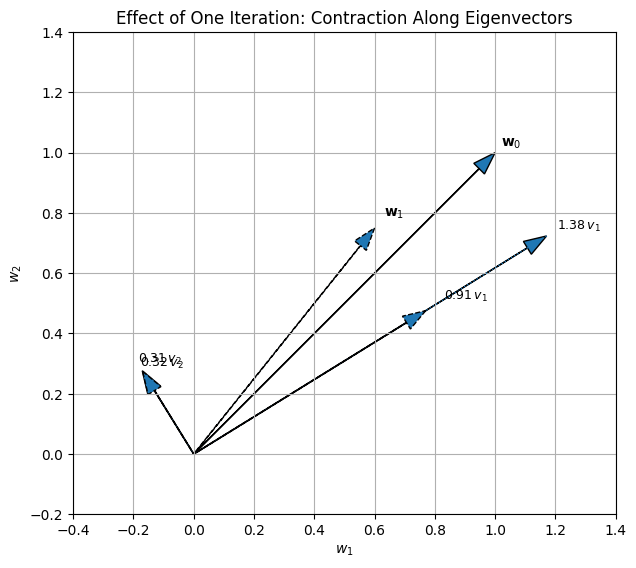

----

7. Recall that true value function is:
$$\text{TD}_1 = \left[ (2 - \pi) D - 1 \right] w_1 + (D - 1) w_2$$
  $$ \text{TD}_2 = \left[ (2 - \pi) D - 2 \right] w_1 + (D - 1) w_2 $$
and
$$
\Delta \mathbf{w} = \alpha \left[ \mu \text{TD}_1 \mathbf{x}_1 + (1 - \mu) \text{TD}_2 \mathbf{x}_2 \right],
$$

$$x_1 = \begin{bmatrix} 1 \\ 1 \end{bmatrix}, x_2 = \begin{bmatrix} 2 \\ 1 \end{bmatrix}$$

Since the starting point is $[1,1]^\top$, we expect $\Delta\mathbb{w}$ can bring $w_1$ and $w_2$ down to 0. $\mu \text{TD}_1$ is the amount we update $\mathbf{w}$ along the line $w_1 = w_2$ and $(1-\mu) \text{TD}_2$ is the amount we update $\mathbf{w}$ along the line $w_1 = 2w_2$.

Also notice $0 \leq (2-\pi)D < 2$ and $D-1 < 0$. Since initially $w_1 > 0, w_2 > 0$, $\text{TD}_2$ is always negative regardless of $\pi$ and $\lambda$ which is what we want. But $\text{TD}_1$ is not always negative as $(2-\pi)D - 1$ could be positive, which will bring $\mathbf{w}$ upwards and diverge. So ideally we should have smaller $\mu$ to put more weight of $s_2$ onto update to make it converge. So if we do the plots with $\mu = 0.2$, we will see more plots converge than $\mu=0.5$. For $\mu=0.8$, we will see less convergent plots.


In [ ]:
M = np.array([[0.75, -0.15], [-0.15, 0.9]])
eigs, eig_vecs = np.linalg.eig(M)
w0 = np.array([1, 1])
eta1, eta2 = eigs
v1 = -eig_vecs[:, 0]
v2 = -eig_vecs[:, 1]
xi1 = np.dot(w0, v1)
xi2 = np.dot(w0, v2)
np.set_printoptions(formatter={'float': lambda x: "{0:0.2f}".format(x)})
print(f"{w0} can be decomposed into {xi1:.2f} * {v1} + {xi2:.2f} * {v2}, where {eta1:.2f} and {eta2:.2f} are eigenvalues.")

[1 1] can be decomposed into 1.38 * [0.85 0.53] + 0.32 * [-0.53 0.85], where 0.66 and 0.99 are eigenvalues.


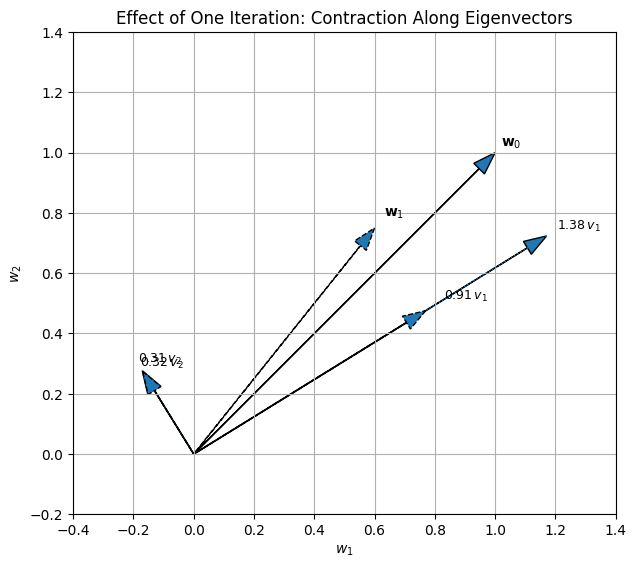

In [ ]:
v1_orig = [xi1 * v1[0], xi1 * v1[1]]
v2_orig = [xi2 * v2[0], xi2 * v2[1]]

v1_contr  = [xi1 * eta1 * v1[0], xi1 * eta1 * v1[1]]
v2_contr  = [xi2 * eta2 * v2[0], xi2 * eta2 * v2[1]]
w1 = [v1_contr[0] + v2_contr[0], v1_contr[1] + v2_contr[1]]

fig, ax = plt.subplots(figsize=(7, 7))

ax.arrow(0, 0, v1_orig[0], v1_orig[1], head_width=0.05, length_includes_head=True)
ax.text(v1_orig[0]*1.03, v1_orig[1]*1.03, r'$1.38\,v_1$', fontsize=9)

ax.arrow(0, 0, v2_orig[0], v2_orig[1], head_width=0.05, length_includes_head=True)
ax.text(v2_orig[0]*1.05, v2_orig[1]*1.05, r'$0.32\,v_2$', fontsize=9)

ax.arrow(0, 0, w0[0], w0[1], head_width=0.05, length_includes_head=True)
ax.text(w0[0]*1.02, w0[1]*1.02, r'$\mathbf{w}_0$', fontsize=10)

ax.arrow(0, 0, v1_contr[0], v1_contr[1], head_width=0.05, length_includes_head=True, linestyle='--')
ax.text(v1_contr[0]*1.08, v1_contr[1]*1.08, r'$0.91\,v_1$', fontsize=9)

ax.arrow(0, 0, v2_contr[0], v2_contr[1], head_width=0.05, length_includes_head=True, linestyle='--')
ax.text(v2_contr[0]*1.10, v2_contr[1]*1.10, r'$0.31\,v_2$', fontsize=9)

ax.arrow(0, 0, w1[0], w1[1], head_width=0.05, length_includes_head=True, linestyle='--')
ax.text(w1[0]*1.05, w1[1]*1.05, r'$\mathbf{w}_1$', fontsize=10)

ax.plot([v1_orig[0], v1_contr[0]], [v1_orig[1], v1_contr[1]], linestyle=':', linewidth=1)

ax.set_xlim(-0.4, 1.4)
ax.set_ylim(-0.2, 1.4)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel(r'$w_1$')
ax.set_ylabel(r'$w_2$')
ax.set_title('Effect of One Iteration: Contraction Along Eigenvectors')
ax.grid(True)

plt.show()